# py4conjoint v0.2.0 動作確認

このノートブックは `py4conjoint` の全公開 API を合成データで動作確認するためのものです。  
実際のアンケートファイルは使わず、numpy で生成した30人分の回答データを用います。

## 0. インストール確認

パッケージが正常にインポートできること、バージョンを確認します。

In [1]:
import py4conjoint as pc
print(pc.__version__)

0.2.0


## 1. 合成データの準備

コンジョイント分析では **カード（プロファイル）** を回答者に提示し、各カードを評価してもらいます。
ここでは価格・OS・カメラの3属性・2水準（各4カード）の設計を使用します。

| カードID | price（万円） | os | camera |
|----------|:-----------:|:-----:|:------:|
| P1 | 6 | android | 標準 |
| P2 | 10 | apple | 標準 |
| P3 | 6 | apple | 高性能 |
| P4 | 10 | android | 高性能 |

`forms_to_conjoint_data()` の出力と同じ **long形式**（1行 = 1人 × 1カード）を生成します。  
想定する真の係数：`price_0 = +1.25`、`os_0 = +0.8`、`camera_0 = +0.6`

In [2]:
import numpy as np
import pandas as pd

cards = pd.DataFrame({
    "price":  [6, 10, 6, 10],
    "os":     ["android", "apple", "apple", "android"],
    "camera": ["標準", "標準", "高性能", "高性能"],
}, index=["P1", "P2", "P3", "P4"])

# 合成回答データ（30人分）を生成
# 真の係数：price_0=+1.25, os_0=+0.8, camera_0=+0.6
rng = np.random.default_rng(42)
rows = []
for resp_id in range(1, 31):
    for card_id, (_, row) in zip(cards.index, cards.iterrows()):
        utility = (
            -1.0 * (1 if row["price"] == 10 else -1)
            + 0.8 * (1 if row["os"] == "apple" else -1)
            + 0.6 * (1 if row["camera"] == "高性能" else -1)
        )
        rating = round(utility * 2 + 5 + rng.normal(0, 0.3))
        rating = max(1, min(7, rating))
        rows.append({
            "回答者ID": resp_id,
            "カードID": card_id,
            "rating": rating,
            "price": row["price"],
            "os": row["os"],
            "camera": row["camera"],
        })
df = pd.DataFrame(rows)

print(f"行数: {len(df)} = {df['回答者ID'].nunique()} 人 × {len(cards)} カード")
df.head(8)

行数: 120 = 30 人 × 4 カード


,回答者ID,カードID,rating,price,os,camera
0,1,P1,4,6,android,標準
1,1,P2,3,10,apple,標準
2,1,P3,7,6,apple,高性能
3,1,P4,3,10,android,高性能
4,2,P1,4,6,android,標準
5,2,P2,3,10,apple,標準
6,2,P3,7,6,apple,高性能
7,2,P4,3,10,android,高性能


## 2. 符号化 — `encode()`

**一行説明**: 属性列を **効果コーディング（-1 / +1）** に変換する。  

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | long形式のデータ |
| `reference_levels` | dict | — | `{"属性名": 基準水準}` の辞書。基準水準が -1 になる |
| `drop_original` | bool | `False` | 元の属性列を削除するか |
| `inplace` | bool | `False` | 入力 df を直接書き換えるか |

**返り値**: 符号化列（`{属性名}_{インデックス}` 形式）が追加された DataFrame  
2水準 → 1列追加（`_0`）、3水準以上 → K-1 列追加（`_0`, `_1`, …）

In [3]:
df_coded = pc.encode(
    df,
    reference_levels={
        "price":  10,       # 高い方を基準 → price_0 列が追加される
        "os":     "android",
        "camera": "標準",
    },
)

print("追加された符号化列:", [c for c in df_coded.columns if c not in df.columns])
df_coded[["回答者ID", "カードID", "rating", "price_0", "os_0", "camera_0"]].head(8)

追加された符号化列: ['price_0', 'os_0', 'camera_0']


,回答者ID,カードID,rating,price_0,os_0,camera_0
0,1,P1,4,1,-1,-1
1,1,P2,3,-1,1,-1
2,1,P3,7,1,1,1
3,1,P4,3,-1,-1,1
4,2,P1,4,1,-1,-1
5,2,P2,3,-1,1,-1
6,2,P3,7,1,1,1
7,2,P4,3,-1,-1,1


## 3. 回帰分析 — `fit()`

**一行説明**: OLS 回帰でコンジョイントモデルを推定し、`ConjointResult` を返す。  

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | `encode()` 済みの DataFrame |
| `rating` | str | `"rating"` | 評点（被説明変数）の列名 |
| `price_col` | str | `"price"` | 価格列名。WTP 計算で使用 |
| `encoded_columns` | list | `None` | 説明変数リスト（省略時は自動検出） |
| `formula` | str | `None` | statsmodels 用の回帰式を直接指定 |

**返り値**: `ConjointResult` — 推定結果と各種解釈メソッドを持つオブジェクト  
`fit()` 直後に落とし穴チェックが自動実行される。

In [4]:
result = pc.fit(df_coded, price_col="price")

## 4. サマリー — `result.summary()`

**一行説明**: 係数表・R²・落とし穴チェック結果をまとめて表示する。  

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `slim` | bool | `True` | コンパクトな統計表を表示するか |

**返り値**: `str` — サマリー文字列  
重大度「大」の落とし穴のみがここに表示される。「中」「小」は `result.warnings()` で確認。

In [5]:
print(result.summary())

コンジョイント分析の結果（和文サマリー）
観測数         : 120
説明変数の数   : 3
決定係数 R²    : 0.9623
自由度修正 R²  : 0.9613

【推定された係数（部分効用 part-worth）】
  Variable                        Coef    p-value   Sig
  ------------------------- ---------- ---------- -----
  Intercept                     4.2417     0.0000   ***
  price_0                       1.2583     0.0000   ***
  os_0                          0.9083     0.0000   ***
  camera_0                      0.5917     0.0000   ***

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1


## 5. 基本プロパティ

| プロパティ | 型 | 説明 |
|-----------|-----|------|
| `params` | `pd.Series` | 推定係数（切片含む） |
| `rsquared` | `float` | 決定係数 R² |
| `n_obs` | `int` | 分析に使用した観測数 |
| `intercept` | `float` | 切片 b₀（全水準平均の効用） |

In [6]:
print('【推定係数 result.params】')
print(result.params)
print()
print(f'【決定係数 result.rsquared】  R² = {result.rsquared:.4f}')
print(f'【観測数    result.n_obs】    n  = {result.n_obs}')
print(f'【切片      result.intercept】b0 = {result.intercept:.4f}')

【推定係数 result.params】
Intercept    4.241667
price_0      1.258333
os_0         0.908333
camera_0     0.591667
dtype: float64

【決定係数 result.rsquared】  R² = 0.9623
【観測数    result.n_obs】    n  = 120
【切片      result.intercept】b0 = 4.2417


## 6. 落とし穴チェック — `result.warnings()`

**一行説明**: 回帰分析で自動検出された落とし穴（診断警告）の一覧を返す。  

**自動検出される警告の種類**

| カテゴリ | 重大度 | 検出タイミング | 内容 |
|----------|:------:|:-----------:|------|
| `r2_low` | 大 | fit() 直後 | R² < 0.20 |
| `few_respondents` | 大/中 | fit() 直後 | 回答者数が少ない |
| `price_sign_negative` | 中 | fit() 直後 | 価格係数の符号が逆 |
| `price_insignificant` | 中 | wtp() 呼出時 | 価格係数の p 値 ≥ 0.10 |
| `wtp_extrapolation` | 大/中 | wtp() 呼出時 | \|WTP\| > 価格レンジ × 2 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `severity` | str / list | `None` | 重大度でフィルタ（`"大"`/`"中"`/`"小"`） |
| `category` | str / list | `None` | カテゴリ名でフィルタ |
| `as_dataframe` | bool | `True` | `True` → DataFrame、`False` → Diagnostic リスト |

**返り値**: `pd.DataFrame`（列: severity, category, message, recommendation）または `list[Diagnostic]`

In [7]:
# まず wtp() を呼んで価格関連の警告も生成させる
_ = result.wtp()

print('【すべての警告】')
all_warnings = result.warnings()
if len(all_warnings) == 0:
    print('  警告なし（データ品質は良好）')
else:
    print(all_warnings.to_string(index=False))

print()
print('【重大度「大」のみ】')
major = result.warnings(severity="大")
print(f'  件数: {len(major)}')

print()
print('【as_dataframe=False（Diagnosticオブジェクトのリスト）】')
diag_list = result.warnings(as_dataframe=False)
print(f"  件数: {len(diag_list)}")
for d in diag_list:
    print(f'  [{d.severity}] {d.category}: {d.message[:50]}...')

【すべての警告】
  警告なし（データ品質は良好）

【重大度「大」のみ】
  件数: 0

【as_dataframe=False（Diagnosticオブジェクトのリスト）】
  件数: 0


## 7. 相対重要度 — `result.importance()`

**一行説明**: 各属性の効用範囲（最大値 − 最小値）の割合として **相対重要度** を計算する。  

**計算式**: `importance_i = range_i / Σ range_j × 100`  
2水準の場合、効用範囲 = `2 × |係数|`（水準が -1 と +1 なので差は 2 倍）

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `as_percent` | bool | `True` | `True` → 合計100%、`False` → 合計1.0 の比率 |

**返り値**: `pd.DataFrame`（インデックス: 属性名、列: `range`, `importance`）  
`importance` の合計は必ず 100.0（または 1.0）になる。

In [8]:
print('【as_percent=True（デフォルト）— 合計100%】')
imp_pct = result.importance(as_percent=True)
print(imp_pct)
print(f"  合計: {imp_pct['importance'].sum():.1f}%")

print()
print('【as_percent=False — 合計1.0の比率】')
imp_ratio = result.importance(as_percent=False)
print(imp_ratio)
print(f"  合計: {imp_ratio['importance'].sum():.4f}")

【as_percent=True（デフォルト）— 合計100%】
           range  importance
属性                          
price   2.516667   45.619335
os      1.816667   32.930514
camera  1.183333   21.450151
  合計: 100.0%

【as_percent=False — 合計1.0の比率】
           range  importance
属性                          
price   2.516667    0.456193
os      1.816667    0.329305
camera  1.183333    0.214502
  合計: 1.0000


## 8. WTP（支払意思額）— `result.wtp()`

**一行説明**: 各非価格属性の WTP（Willingness to Pay）を計算する。  
「その属性を基準水準から非基準水準に変えるとき、回答者が最大いくら追加で支払うか」を金額で表す。

**計算式**: `WTP = unit_rating_money × b_attr`  
ここで `unit_rating_money = (price_max − price_min) / (|b_price| × 2)`

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `pd.DataFrame`（インデックス: 符号化列名、列: `coef`, `wtp`）  
価格列と同じ単位（万円・千円・円など）で返される。

In [9]:
wtp_df = result.wtp()
print(wtp_df)

               coef       wtp
属性（符号化列名）                    
os_0       0.908333  2.887417
camera_0   0.591667  1.880795


## 9. 評点1点の円換算 — `result.unit_rating_money()`

**一行説明**: 評点 1 ポイントが何円（または何万円）に相当するかを `float` で返す。  

**計算式**: `(price_max − price_min) / (|b_price| × 2)`  
効果コーディングで価格変数が -1 〜 +1 の範囲をとるため、効用範囲は `|b_price| × 2` になる。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `float` — 価格列と同じ単位

In [10]:
unit = result.unit_rating_money()
print(f"評点1点 = {unit:.4f} 万円")

# 手計算で確認
b_price = result.params["price_0"]
print(f"検算: (10-6) / abs({b_price:.4f} × 2) = {(10-6)/abs(b_price*2):.4f}")

評点1点 = 1.5894 万円
検算: (10-6) / abs(1.2583 × 2) = 1.5894


## 10. 市場シェア予測 — `result.market_share()`

**一行説明**: 複数製品の効用を推定し、市場シェアを予測する。  

**計算方法**
- `"logit"`（デフォルト）: ソフトマックス型。`share_i = exp(u_i) / Σ exp(u_j)`
- `"max"`: 最大効用ルール。最も効用が高い製品にシェア 1.0、他は 0。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `products` | DataFrame | — | 製品 × 符号化列の DataFrame |
| `method` | str | `"logit"` | シェア計算方法（`"logit"` または `"max"`） |

**返り値**: `pd.Series`（インデックス: 製品名、値: シェア 0〜1）  
合計は必ず 1.0 になる。

In [11]:
products = pd.DataFrame(
    {
        "price_0":  [ 1, -1,  1],   # 6万円=1, 10万円=-1
        "os_0":     [ 1,  1, -1],   # apple=1, android=-1
        "camera_0": [ 1,  1, -1],   # 高性能=1, 標準=-1
    },
    index=["製品A（6万・apple・高性能）", "製品B（10万・apple・高性能）", "製品C（6万・android・標準）"],
)

print('【method="logit"（デフォルト）】')
share_logit = result.market_share(products, method="logit")
print(share_logit)
print(f"  合計: {share_logit.sum():.6f}")

print()
print('【method="max"（最大効用ルール）】')
share_max = result.market_share(products, method="max")
print(share_max)
print(f"  合計: {share_max.sum():.6f}")

【method="logit"（デフォルト）】
製品A（6万・apple・高性能）     0.884552
製品B（10万・apple・高性能）    0.071408
製品C（6万・android・標準）    0.044039
Name: market_share, dtype: float64
  合計: 1.000000

【method="max"（最大効用ルール）】
製品A（6万・apple・高性能）     1.0
製品B（10万・apple・高性能）    0.0
製品C（6万・android・標準）    0.0
Name: market_share, dtype: float64
  合計: 1.000000


## 11. 可視化

| メソッド | 説明 |
|----------|------|
| `plot_importance()` | 属性の相対重要度を水平棒グラフで表示（重要度順ソート） |
| `plot_partworth()` | 各水準の部分効用（パートワース）を属性ごとに色分けして表示 |
| `plot_wtp(price_unit=)` | 各属性の WTP を水平棒グラフで表示（単位ラベル付き） |

すべて `matplotlib.axes.Axes` を返すので、`ax.set_title()` 等で後から調整できる。

<Axes: title={'center': '属性の相対重要度'}, xlabel='相対重要度（%）'>

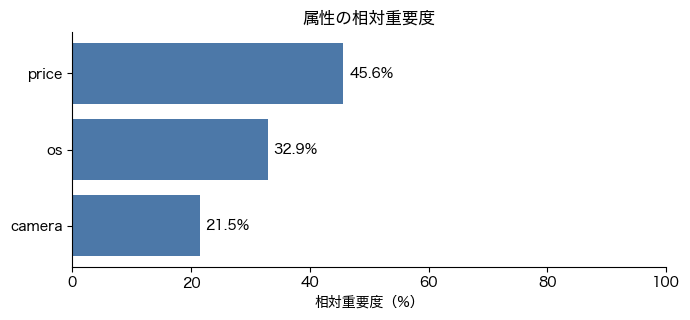

In [12]:
result.plot_importance()

<Axes: title={'center': '部分効用（パートワース）'}, xlabel='部分効用（評点ポイント）'>

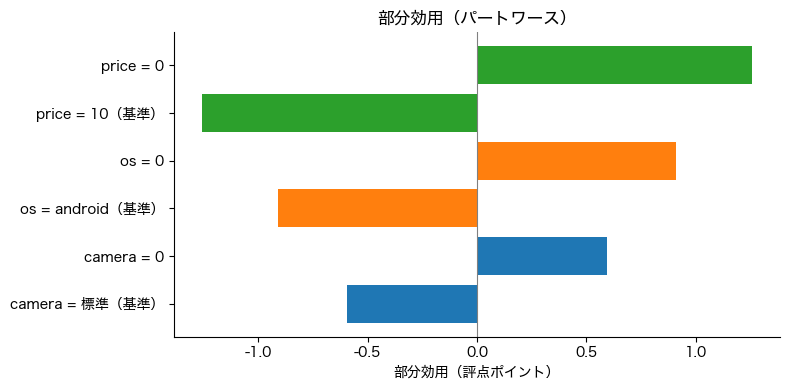

In [13]:
result.plot_partworth()

<Axes: title={'center': '属性のWTP（支払意思額）'}, xlabel='WTP（支払意思額）（万円）'>

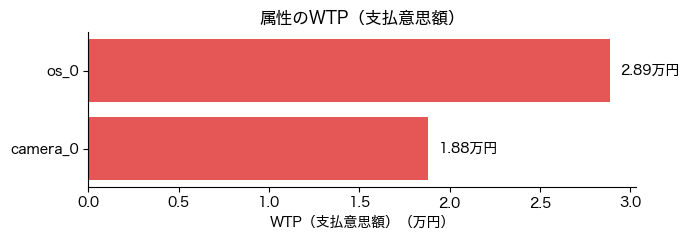

In [14]:
result.plot_wtp(price_unit="万円")